In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [8]:
df.shape

(32581, 12)

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [10]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

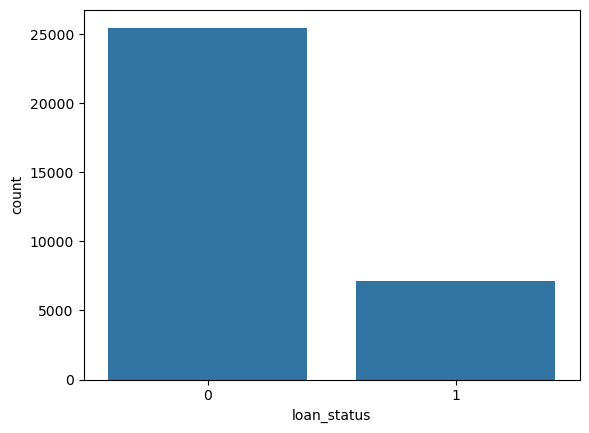

In [12]:
sns.countplot(x='loan_status', data=df)

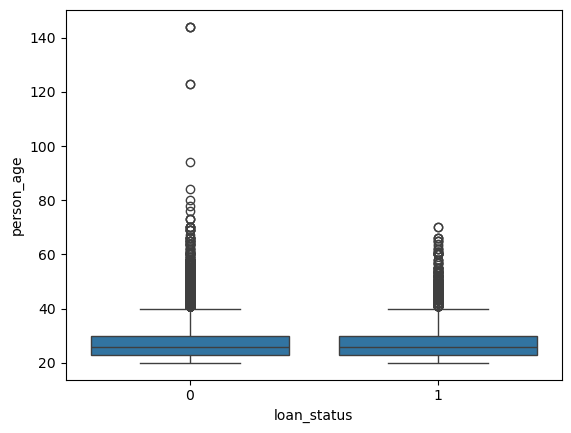

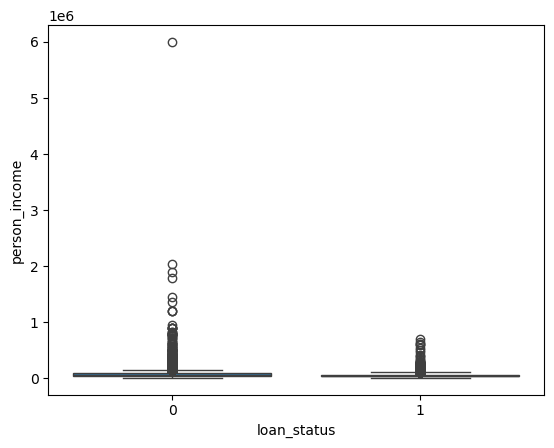

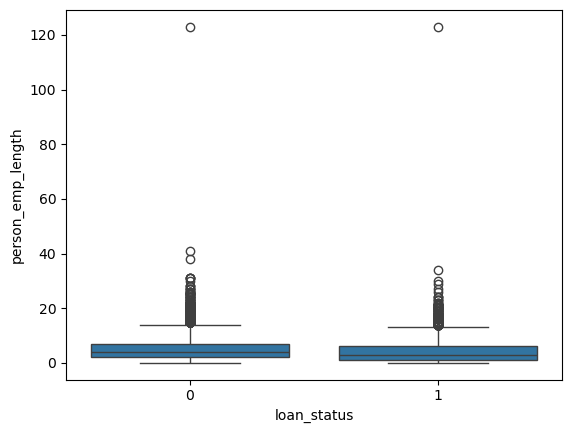

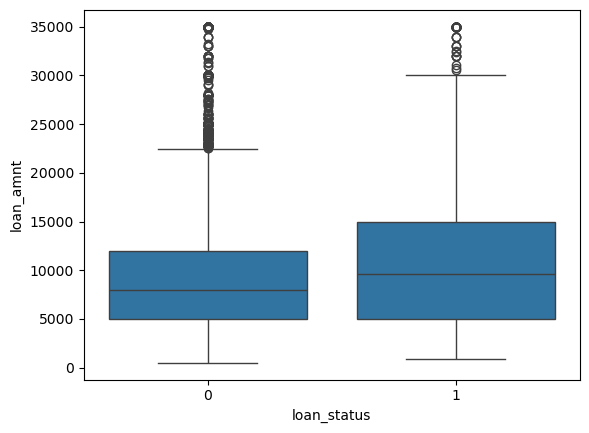

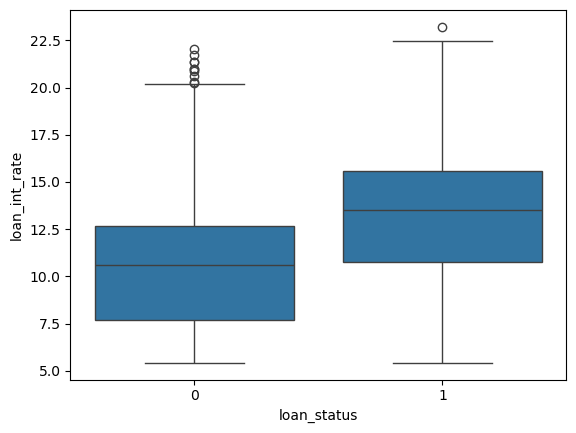

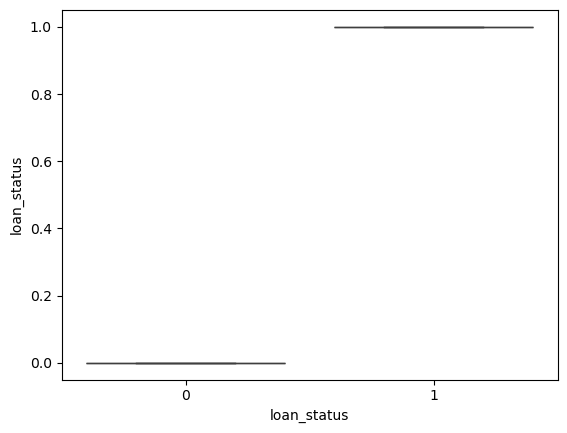

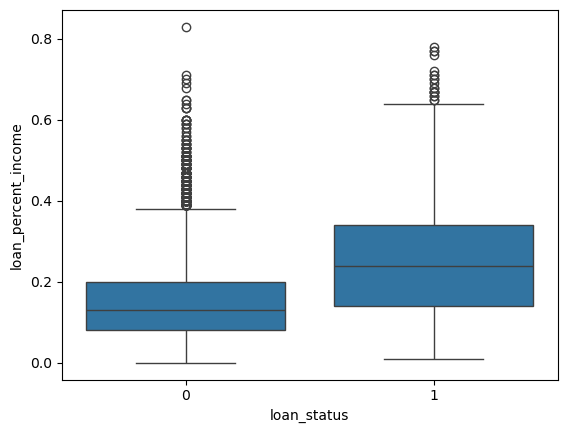

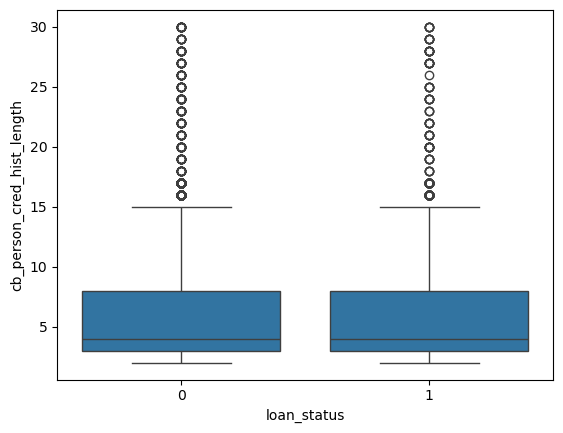

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
for i in numerical_cols:
    sns.boxplot(x='loan_status', y=i, data=df)
    plt.show()

    

In [13]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

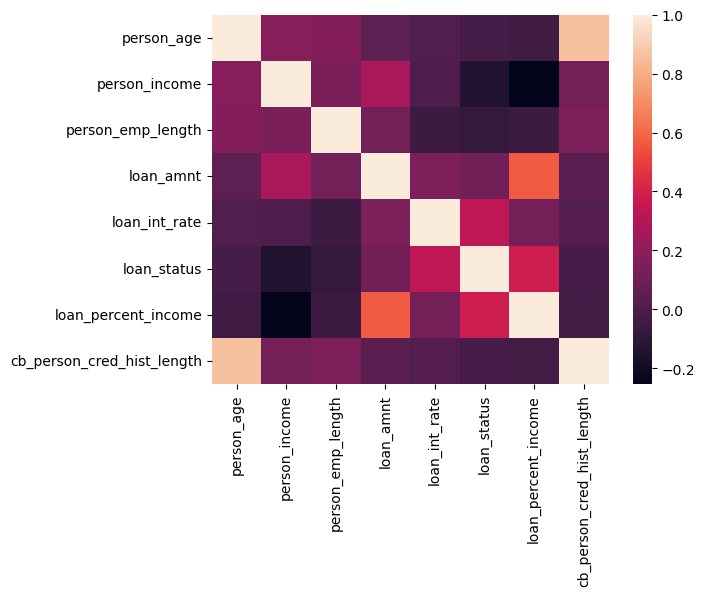

In [24]:
sns.heatmap(df.corr(numeric_only=True))

In [27]:
df_copy = df.copy()
df_copy.drop_duplicates(inplace=True)

In [36]:
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

df_copy = df_copy[df_copy['loan_amnt'] > 0]

In [37]:
X = df_copy.drop('loan_status', axis=1)
Y = df_copy['loan_status']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [72]:
numeric_cols = ['person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_income' ]
categorical_cols = ['person_home_ownership',  'loan_intent', 'cb_person_default_on_file']

In [73]:
neg , pos = np.bincount(Y_train)
scale_weights = neg/pos

In [74]:
scale_weights


np.float64(3.6312213039485766)

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]), numeric_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])

In [76]:
preprocessor_xg = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [78]:
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([('preprocessor', preprocessor_lr),
                           ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight ="balanced"))])
lr_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([('preprocessor', preprocessor_xg),
          ('classifier', XGBClassifier(n_estimators=300,max_depth=5, learning_rate=0.1,
                                        random_state=42, scale_pos_weight=scale_weights))])

In [89]:
from sklearn.model_selection import cross_validate

for cv_name, pipe in [('LogisticRegression', lr_cv_pipeline), ('XGBoost', xgb_cv_pipeline)]:
    cv_results =cross_validate(pipe, X_train, Y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)

    print(cv_name)
    print(f"ROC-AUC:{cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy:{cv_results['test_accuracy'].mean()}")
    print(f"Precision:{cv_results['test_precision'].mean()}")
    print(f"Recall:{cv_results['test_recall'].mean()}")
    print(f"F1:{cv_results['test_f1'].mean()}")

LogisticRegression
ROC-AUC:0.8499208626236461
Accuracy:0.7704320795166327
Precision:0.4804081129180475
Recall:0.7682277318640954
F1:0.5910836669402715
XGBoost
ROC-AUC:0.9388884776993237
Accuracy:0.9035968309335904
Precision:0.7702444585842011
Recall:0.7891643709825529
F1:0.7794773500270605


In [94]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('Preprocessor',preprocessor_lr),
    ('Classifier',LogisticRegression(class_weight ="balanced"))
])
baseline_model.fit(X_train, Y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [132]:
#We have to evaluate logistic model and xgboost model on the basis of their metrics.
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
def evaluate_model(model_name,model, X_test, Y_test,threshold = None):
    Y_pred = model.predict(X_test)
    Y_pred_prob = model.predict_proba(X_test)[:,1]

    if threshold:
        Y_pred = (Y_pred_prob >= threshold).astype(int)
    else:
        Y_pred = model.predict(X_test)

    #metrics 
    accuracy = accuracy_score(Y_test, Y_pred) #overall model's performance
    precision = precision_score(Y_test, Y_pred) #of the ones i predicted as positive, how many were actually right
    recall = recall_score(Y_test, Y_pred) #of the ones that were actually positive, how many did i predict as positive
    f1 = f1_score(Y_test, Y_pred) #harmonic mean of precision and recall
    roc_auc = roc_auc_score(Y_test, Y_pred_prob) #area under the ROC curve

    #confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    class_report = classification_report(Y_test, Y_pred)

    print (f"accuracy: {accuracy:.2f}")
    print (f"precision: {precision:.2f}")
    print (f"recall: {recall:.2f}")
    print (f"f1: {f1:.2f}")
    print (f"roc_auc: {roc_auc:.2f}")

    #Plotting confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    #Plotting ROC AUC curve
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.show()

In [109]:
xg_model = Pipeline([('Preprocessor',preprocessor_xg),
    ('Classifier',XGBClassifier(n_estimators=300,max_depth=5, learning_rate=0.1,
                                        random_state=42, scale_pos_weight=scale_weights))])
xg_model.fit(X_train, Y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


accuracy: 0.78
precision: 0.50
recall: 0.79
f1: 0.61
roc_auc: 0.86


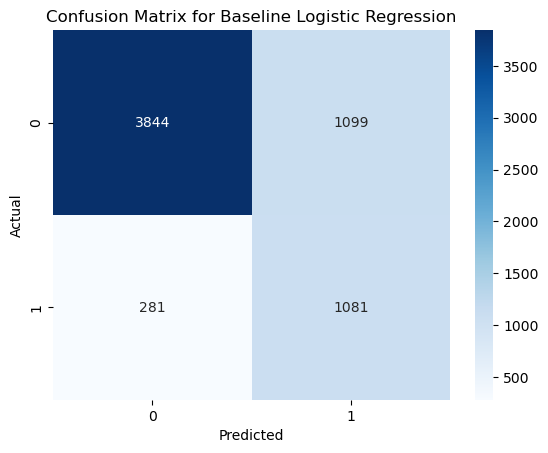

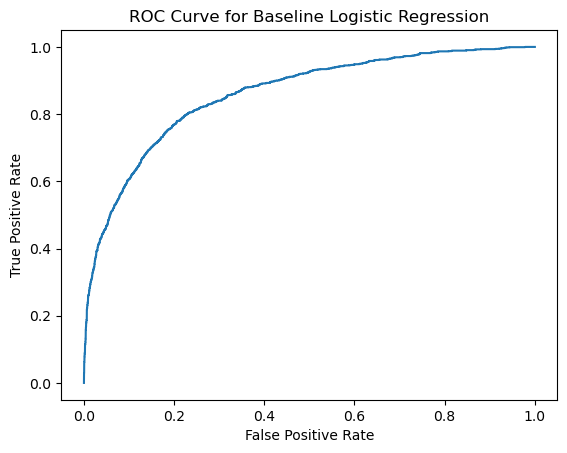

In [110]:
#Evaluate the logistic model

evaluate_model('Baseline Logistic Regression', baseline_model, X_test, Y_test)


accuracy: 0.91
precision: 0.77
recall: 0.80
f1: 0.78
roc_auc: 0.94


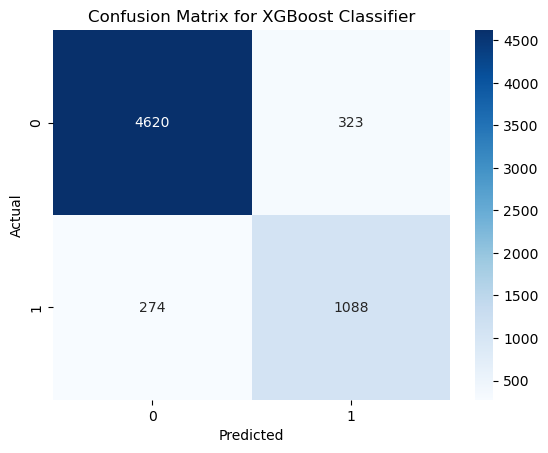

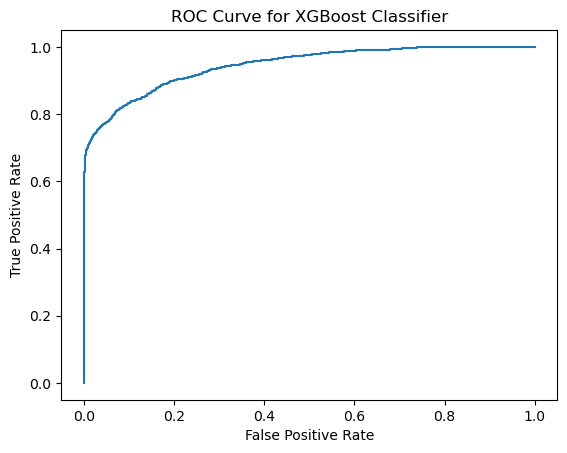

In [111]:
evaluate_model('XGBoost Classifier', xg_model, X_test, Y_test)

In [126]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint 


param_grid = {
    "Classifier__n_estimators": randint(150,600), 
    "Classifier__max_depth": randint(3,9),
    "Classifier__learning_rate": uniform(0.01, 0.5),
    "Classifier__subsample": uniform(0.6, 0.4),  #rows sampling 
    "Classifier__colsample_bytree": uniform(0.6, 0.4),  #columns sampling
    "Classifier__min_child_weight": randint(1, 10),  #minimum sum of instance weight(hessian) needed in a child
    "Classifier__gamma": uniform(0,5)
}

#lower gamma -> more splits -> complex tree -> higher overfitting chances
#higher gamma -> less splits -> simpler tree -> low overfitting chances 

In [127]:
random_search = RandomizedSearchCV(
    xg_model, 
    param_distributions=param_grid, 
    n_iter=50, 
    scoring='roc_auc', 
    cv=cv, 
    verbose=1, 
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'Classifier__colsample_bytree': <scipy.stats....t 0x1386b8b90>, 'Classifier__gamma': <scipy.stats....t 0x1386b8d70>, 'Classifier__learning_rate': <scipy.stats....t 0x1385d2350>, 'Classifier__max_depth': <scipy.stats....t 0x1337a5040>, ...}"
,n_iter,50
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [128]:
random_search.best_params_

{'Classifier__colsample_bytree': np.float64(0.902144564127061),
 'Classifier__gamma': np.float64(2.1257793724562237),
 'Classifier__learning_rate': np.float64(0.11397083143409441),
 'Classifier__max_depth': 6,
 'Classifier__min_child_weight': 6,
 'Classifier__n_estimators': 340,
 'Classifier__subsample': np.float64(0.9369139098379994)}

In [130]:
print(f"Score after performing tunning: {random_search.best_score_:0.2f}")

Score after performing tunning: 0.94


accuracy: 0.91
precision: 0.77
recall: 0.80
f1: 0.78
roc_auc: 0.94


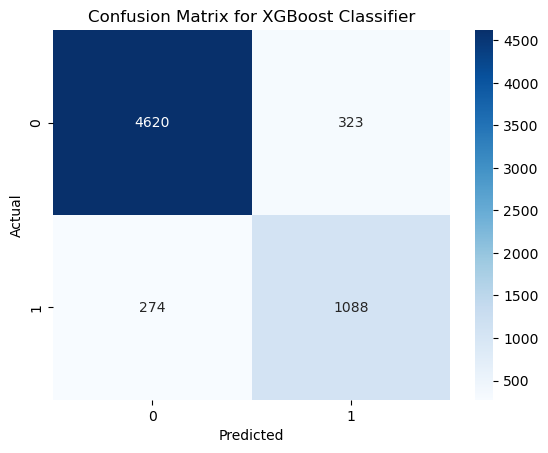

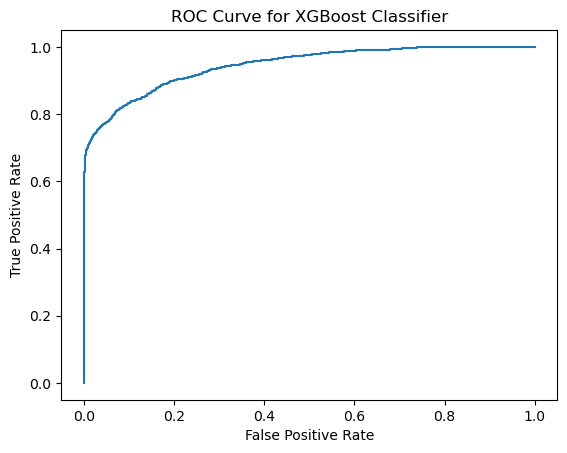

In [131]:
evaluate_model('XGBoost Classifier', xg_model, X_test, Y_test)

accuracy: 0.93
precision: 0.93
recall: 0.73
f1: 0.82
roc_auc: 0.94


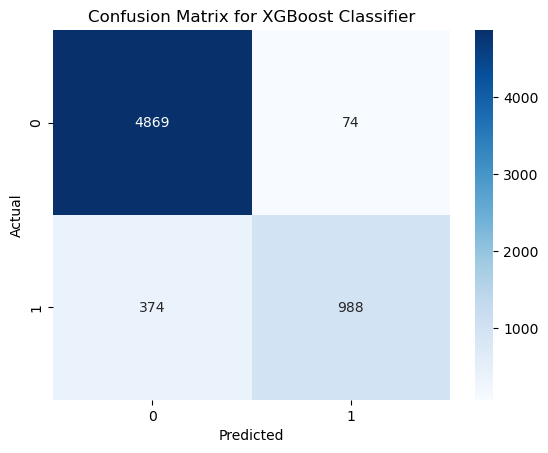

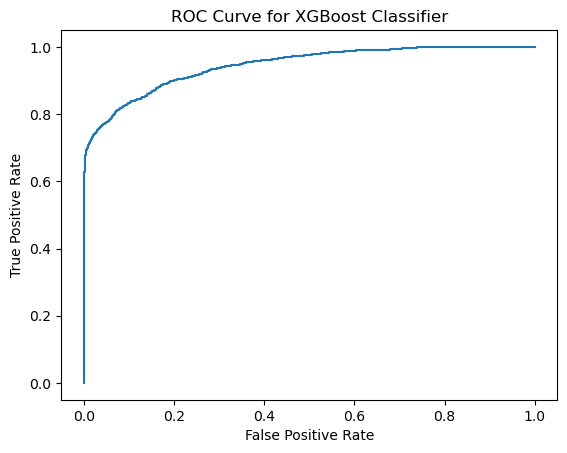

In [ ]:
#Get the probability of class 1 from xg boost 
prob = xg_model.predict_proba(X_test)[0:,1]

# For each threshold calculate precision and recall
precision, recall, thresholds = precision_recall_curve(Y_test, prob)

# Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

#Get the threshold that produces the best F1 score
best_threshold = thresholds[np.argmax(f1_scores)]

#Evaluate the xg boost model using that f1 score
evaluate_model('XGBoost Classifier', xg_model, X_test, Y_test, threshold=best_threshold)



In [186]:
#Probability Calibration

# 1) Calibrate XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, Y_train)


,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [187]:
# 2) Get probabilities
uncalibrated_probs = xg_model.predict_proba(X_test)[:, 1]
calibrated = calibrated_model.predict_proba(X_test)[:, 1]

In [188]:
# 3) create calibration curve
actual_uncalibrated, predicted_uncalibrated = calibration_curve(Y_test, uncalibrated_probs, n_bins=10)

In [189]:
actual_calibrated, predicted_calibrated = calibration_curve(Y_test, calibrated, n_bins=10)

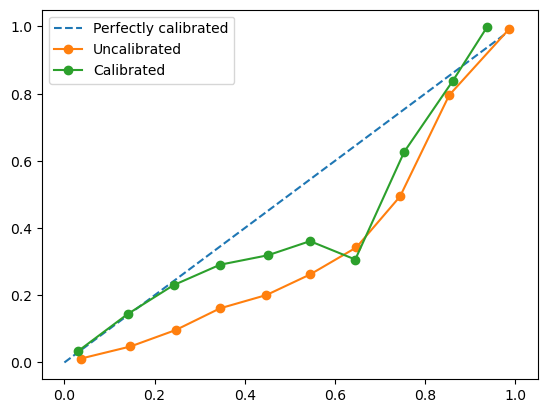

In [190]:
# 4) plot calibration curve
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.plot(predicted_uncalibrated, actual_uncalibrated, marker='o', label='Uncalibrated')
plt.plot(predicted_calibrated, actual_calibrated, marker='o', label='Calibrated')
plt.legend()


In [191]:
import shap


In [192]:
xgb_classifier = xg_model.named_steps['Classifier']
xgb_classifier

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [193]:
X_test_transformed = xg_model.named_steps['Preprocessor'].transform(X_test)

In [194]:
feature_names = xg_model.named_steps['Preprocessor'].get_feature_names_out()

In [195]:
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [196]:
explainer = shap.TreeExplainer(xgb_classifier)

In [197]:
shap_values = explainer.shap_values(X_test_df)

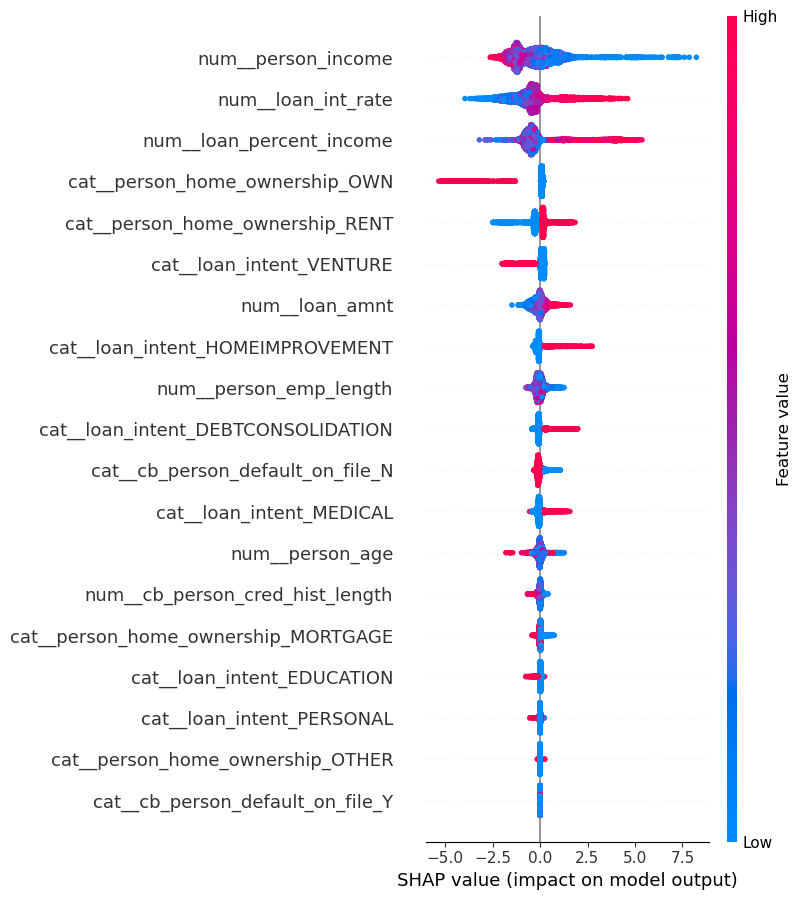

In [198]:
shap.summary_plot(shap_values,X_test_df)

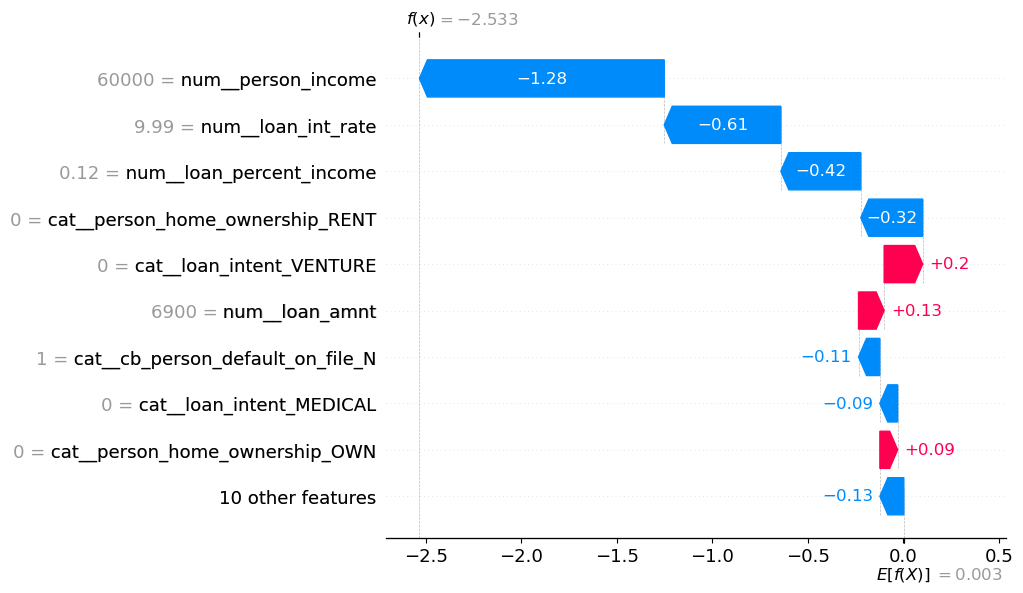

In [199]:
row_index = 5

shap.plots.waterfall(
    shap.Explanation(
    values=shap_values[row_index],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[row_index],
    feature_names=feature_names
))

In [200]:
Y_pred = random_search.predict(X_test)

In [201]:
result_Df = X_test.copy()
result_Df['Actual'] = Y_test
result_Df['Predicted'] = Y_pred

In [202]:
result_Df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual,Predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,0
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,1
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [203]:
false_positive = (result_Df[(result_Df['Actual'] == 0) & (result_Df['Predicted'] == 1)])

false_negative = (result_Df[(result_Df['Actual'] == 1) & (result_Df['Predicted'] == 0)])

In [204]:
print(f"False Positives: {len(false_positive)}")
print(f"False Negatives: {len(false_negative)}")

False Positives: 301
False Negatives: 277


In [205]:
import joblib
joblib.dump(calibrated_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [208]:
joblib.dump(best_threshold, 'best_threshold.pkl')

['best_threshold.pkl']

In [207]:
from sklearn.metrics import precision_recall_curve

calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(Y_test, calibrated_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold for F1 score: {best_threshold:.2f}")

Best threshold for F1 score: 0.68
